# **Fine-Tuning Sentence-BERT untuk Sistem Job Recomendation ITCareerMatch**

Notebook ini berisi seluruh proses pengembangan model Sentence-BERT (SBERT) yang digunakan pada platform ITCareerMatch, mulai dari persiapan data, tokenisasi, pembangunan arsitektur Siamese Network, konfigurasi pelatihan, proses fine-tuning, hingga evaluasi performa model.

Tujuan utama fine-tuning adalah menghasilkan model yang mampu memprediksi tingkat kecocokan (*match score*) antara CV dan deskripsi pekerjaan secara akurat sehingga dapat digunakan sebagai dasar sistem rekomendasi pekerjaan yang lebih personal dan relevan.

# **1. Import Library dan Config**

In [3]:
import os
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel
from tensorflow.keras import mixed_precision
from sklearn.model_selection import train_test_split

# Mixed Precision untuk optimasi memori GPU
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Config Model
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MAX_LEN = 300
BATCH_SIZE = 32
EPOCHS = 20
LR_INIT = 2e-5

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **2. Load Dataset dan Split Data**

Muat dataset `final_dataset.csv` yang telah disiapkan tim DS, lalu mengonversi label ke tipe `float32` agar kompatibel dengan mixed precision. Setelah itu, menampilkan informasi dasar dataset dan membaginya menjadi train, validation, dan test dengan proporsi 80:10:10.

In [2]:
# Load Dataset
df = pd.read_csv("final_dataset.csv")

# Memastikan label dalam format float32 untuk kompatibilitas dengan mixed precision
df["match_label"] = df["match_label"].astype(np.float32)

print("Info Dataset:")
print(df.info())

# Split Data (train, val, test) dengan proporsi 80:10:10
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("\nPembagian Dataset:")
print("Jumlah Data Train:", len(train_df))
print("Jumlah Data Val  :", len(val_df))
print("Jumlah Data Test :", len(test_df))

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   job_desc     150000 non-null  object 
 1   resume       150000 non-null  object 
 2   match_label  150000 non-null  float32
 3   bin          150000 non-null  object 
dtypes: float32(1), object(3)
memory usage: 4.0+ MB
None

Pembagian Dataset:
Jumlah Data Train: 120000
Jumlah Data Val  : 15000
Jumlah Data Test : 15000


# **3. Check Panjang Text**

Mengambil sampel teks (job description dan CV), melakukan tokenisasi, lalu menghitung **min / max / rata‑rata** panjang token untuk memahami distribusi panjang input.

In [4]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Analisis panjang token dari 1000 sampel acak untuk job_desc dan resume
print("Menghitung distribusi panjang token...")
sample_df = df.sample(min(1000, len(df)))
job_lengths = sample_df['job_desc'].apply(lambda x: len(tokenizer.tokenize(str(x))))
cv_lengths = sample_df['resume'].apply(lambda x: len(tokenizer.tokenize(str(x))))

print("\n--- Analisis Panjang Token Job Desc ---")
print(f"Min: {job_lengths.min()} | Max: {job_lengths.max()} | Rata-rata: {job_lengths.mean():.0f}")

print("\n--- Analisis Panjang Token CV ---")
print(f"Min: {cv_lengths.min()} | Max: {cv_lengths.max()} | Rata-rata: {cv_lengths.mean():.0f}")

/home/ulil/miniconda3/envs/gpu_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Menghitung distribusi panjang token...


Token indices sequence length is longer than the specified maximum sequence length for this model (620 > 512). Running this sequence through the model will result in indexing errors



--- Analisis Panjang Token Job Desc ---
Min: 16 | Max: 620 | Rata-rata: 187

--- Analisis Panjang Token CV ---
Min: 6 | Max: 152 | Rata-rata: 82


# **4. Encoding Teks dan Buat tf.data**

Melakukan tokenisasi seluruh teks menggunakan `MAX_LEN` yang sudah ditentukan, lalu mengonversi label ke tensor dan membangun `tf.data.Dataset` untuk **train / val / test**. Tujuannya: menyiapkan data dalam format yang efisien untuk training.

In [ ]:
# Melakukan proses tokenisasi pada seluruh dataset
def encode_texts(texts_array):
    tokens = tokenizer(
        texts_array.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )
    return {
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"]
    }

print("Melakukan proses tokenisasi pada data Train...")
train_job_tokens = encode_texts(train_df["job_desc"])
train_cv_tokens = encode_texts(train_df["resume"])

print("Melakukan proses tokenisasi pada data Validation...")
val_job_tokens = encode_texts(val_df["job_desc"])
val_cv_tokens = encode_texts(val_df["resume"])

print("Melakukan proses tokenisasi pada data Test...")
test_job_tokens = encode_texts(test_df["job_desc"])
test_cv_tokens = encode_texts(test_df["resume"])

# Konversi Label ke format Tensor
y_train = tf.convert_to_tensor(train_df["match_label"].values, dtype=tf.float32)
y_val = tf.convert_to_tensor(val_df["match_label"].values, dtype=tf.float32)
y_test = tf.convert_to_tensor(test_df["match_label"].values, dtype=tf.float32)

# Membuat tf.data.Dataset dari token dan label
def build_tf_dataset(job_tokens, cv_tokens, labels, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        (job_tokens["input_ids"], job_tokens["attention_mask"], 
         cv_tokens["input_ids"], cv_tokens["attention_mask"]), 
        labels
    ))
    if is_training:
        dataset = dataset.shuffle(10000)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = build_tf_dataset(train_job_tokens, train_cv_tokens, y_train, is_training=True)
val_dataset = build_tf_dataset(val_job_tokens, val_cv_tokens, y_val)
test_dataset = build_tf_dataset(test_job_tokens, test_cv_tokens, y_test)

Melakukan proses tokenisasi pada data Train...
Melakukan proses tokenisasi pada data Validation...
Melakukan proses tokenisasi pada data Test...


# **5. Custom Layer**

Mendefinisikan beberapa **custom layer** untuk mendukung arsitektur SBERT:
- **MeanPooling** → merata-ratakan embedding token dengan memperhatikan `attention_mask`.
- **L2Normalize** → melakukan normalisasi vektor agar berada pada unit sphere.
- **ScaleTo01** → mengubah range output dari `[-1, 1]` menjadi `[0, 1]`.

In [7]:
# Custom Mean Pooling Layer
@tf.keras.utils.register_keras_serializable()
class MeanPooling(tf.keras.layers.Layer):
    def call(self, inputs):
        token_embeddings, attention_mask = inputs
        mask = tf.cast(tf.expand_dims(attention_mask, axis=-1), dtype=token_embeddings.dtype)
        masked = token_embeddings * mask
        sum_embeddings = tf.reduce_sum(masked, axis=1)
        sum_mask = tf.reduce_sum(mask, axis=1)
        return sum_embeddings / tf.clip_by_value(sum_mask, 1e-9, 1e9)

# Custom L2 Normalization Layer
@tf.keras.utils.register_keras_serializable()
class L2Normalize(tf.keras.layers.Layer):
    def __init__(self, axis=1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

# Scaling Layer untuk mengubah range dari [-1, 1] ke [0, 1]
@tf.keras.utils.register_keras_serializable()
class ScaleTo01(tf.keras.layers.Layer):
    def call(self, inputs):
        return (inputs + 1.0) / 2.0

# **6. Build Model**

Membangun **Siamese Model** dengan Functional API menggunakan pre-trained BERT.  
Langkah utama:
- Membuat input layer untuk job description dan CV.  
- Memuat BERT, membekukan sebagian besar layer, lalu membuka 1 layer terakhir untuk fine-tuning.  
- Menggunakan **MeanPooling** untuk menghasilkan vektor representasi.  
- Menambahkan projection head (Dense + Dropout) untuk pemetaan ke dimensi lebih kecil.  
- Normalisasi dengan **L2Normalize**, lalu menghitung **cosine similarity**.  
- Skor kecocokan diubah ke rentang `[0,1]` dengan **ScaleTo01** dan dijadikan output akhir `final_score`.  

Hasilnya adalah model utama `ITCareerMatch_Siamese` untuk menghitung skor kecocokan, serta `ITCareerMatch_Encoder` untuk menghasilkan embedding job.

In [8]:
# Membangun Functional API Model Siamese
def build_siamese_model(max_len: int = MAX_LEN, model_name: str = MODEL_NAME):
    # Input layers
    input_job_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="job_input_ids")
    input_job_mask = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="job_attention_mask")
    input_cv_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="cv_input_ids")
    input_cv_mask = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="cv_attention_mask")

    # Load Pre-trained BERT Model dan Freeze semua layer
    base_bert_model = TFAutoModel.from_pretrained(model_name)
    base_bert_model.trainable = True 
    base_bert_model.bert.embeddings.trainable = False
    base_bert_model.bert.pooler.trainable = False
    
    for layer in base_bert_model.bert.encoder.layer:
        layer.trainable = False

    # Unfreeze 1 layer terakhir untuk fine-tuning
    for layer in base_bert_model.bert.encoder.layer[-1:]:
        layer.trainable = True

    # Inisiasi Pooling Layer
    mean_pooling_layer = MeanPooling(name="mean_pooling")

    # Ekstraksi embedding dari BERT
    job_embedding_out = base_bert_model(input_ids=input_job_ids, attention_mask=input_job_mask)[0]
    cv_embedding_out = base_bert_model(input_ids=input_cv_ids, attention_mask=input_cv_mask)[0]

    job_pooled_vec = mean_pooling_layer([job_embedding_out, input_job_mask])
    cv_pooled_vec = mean_pooling_layer([cv_embedding_out, input_cv_mask])

    # Projection Head
    dense_layer = tf.keras.layers.Dense(128, activation="relu", name="proj_dense")
    dropout_layer = tf.keras.layers.Dropout(0.3, name="proj_dropout")
    projection_layer = tf.keras.layers.Dense(64, activation=None, name="proj_out")

    job_projected = projection_layer(dropout_layer(dense_layer(job_pooled_vec)))
    cv_projected = projection_layer(dropout_layer(dense_layer(cv_pooled_vec)))

    # L2 Normalization
    l2_normalization = L2Normalize(name="l2_normalize")
    job_normalized = l2_normalization(job_projected)
    cv_normalized = l2_normalization(cv_projected)

    # Hitung Cosine Similarity dan Scaling ke [0, 1]
    cosine_similarity = tf.keras.layers.Dot(axes=1, normalize=False, name="cosine_similarity")([job_normalized, cv_normalized])
    scaled_similarity = ScaleTo01(name="scaled_similarity")(cosine_similarity)
    final_match_score = tf.keras.layers.Activation("linear", dtype="float32", name="final_score")(scaled_similarity)

    model = tf.keras.Model(
        inputs=[input_job_ids, input_job_mask, input_cv_ids, input_cv_mask], 
        outputs=final_match_score, 
        name="ITCareerMatch_Siamese"
    )
    
    encoder_model = tf.keras.Model(
        inputs=[input_job_ids, input_job_mask], 
        outputs=job_normalized, 
        name="ITCareerMatch_Encoder"
    )

    return model, encoder_model

model, encoder_model = build_siamese_model()
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['embeddings.position_ids']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.
/home/ulil/miniconda3/envs/gpu_env/lib/python3.10/site-packages/tensorflow/python/framework/tensor_util.py:522: RuntimeWarning: overflow encountered in cast
  nparray = np.array(values, dtype=np_dt)


Model: "ITCareerMatch_Siamese"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 job_input_ids (InputLayer)  [(None, 300)]                0         []                            
                                                                                                  
 job_attention_mask (InputL  [(None, 300)]                0         []                            
 ayer)                                                                                            
                                                                                                  
 cv_input_ids (InputLayer)   [(None, 300)]                0         []                            
                                                                                                  
 cv_attention_mask (InputLa  [(None, 300)]                0         []        

# **7. Loss Function dan TensorBoard**

Menggunakan **Mean Squared Error (MSE)** sebagai loss function untuk menghitung selisih antara skor prediksi dan label sebenarnya.  
Selain itu, menyiapkan direktori log TensorBoard untuk memantau proses training (train/val).

### Cara akses TensorBoard
1. Buka terminal baru.  
2. Jalankan perintah:  
   tensorboard --logdir logs/fit

In [ ]:
# Loss Function Mean Squared Error (MSE) 
mse_metric_fn = tf.keras.losses.MeanSquaredError()

def compute_loss(y_true, y_pred):
    y_true = tf.expand_dims(y_true, axis=-1)
    return mse_metric_fn(y_true, y_pred)

# Setup TensorBoard
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_log_dir = 'logs/fit/' + current_time + '/train'
val_log_dir = 'logs/fit/' + current_time + '/val'

train_summary_writer = tf.summary.create_file_writer(train_log_dir)
val_summary_writer = tf.summary.create_file_writer(val_log_dir)

print(f"Direktori Log TensorBoard: logs/fit/{current_time}")

Direktori Log TensorBoard: logs/fit/20260529-052757


# **8. Optimizer dan Metrics**

Menghitung total langkah pelatihan, lalu menggunakan **Cosine Decay Learning Rate Scheduler** untuk menyesuaikan laju belajar secara bertahap.  
Optimizer yang dipakai adalah **AdamW** dengan mixed precision agar lebih efisien.  

Selain itu, menyiapkan metrik untuk memantau performa model:
- **Mean Absolute Error (MAE)** → mengukur selisih rata-rata antara prediksi dan label.  
- **Binary Accuracy** → menilai akurasi prediksi kecocokan (threshold 0.5).  

Metrik ini dicatat untuk data **train** dan **validation** selama proses training.

In [10]:
# Menghitung total langkah pelatihan untuk scheduler
steps_per_epoch = len(train_df) // BATCH_SIZE
total_training_steps = steps_per_epoch * EPOCHS

# Cosine Decay Learning Rate Scheduler
learning_rate_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_INIT,
    decay_steps=total_training_steps,
    alpha=0.1
)

# Konfigurasi Optimizer dengan Mixed Precision
optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate_scheduler, weight_decay=1e-4)
optimizer = mixed_precision.LossScaleOptimizer(optimizer)

# Metrik untuk melacak MAE dan Akurasi
train_mae_tracker = tf.keras.metrics.MeanAbsoluteError(name="train_mae")
val_mae_tracker = tf.keras.metrics.MeanAbsoluteError(name="val_mae")

train_acc_tracker = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name="train_acc")
val_acc_tracker = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name="val_acc")

# **9.  Custom Training**

Mendefinisikan fungsi **training step** dan **validation step** secara manual menggunakan **tf.GradientTape**.  
- Pada training step: model melakukan forward pass, menghitung loss, scaling gradien, lalu meng-update parameter dengan optimizer.  
- Pada validation step: model hanya melakukan forward pass dan menghitung loss, kemudian memperbarui metrik validasi.

In [11]:
# Training step
@tf.function
def execute_train_step(inputs, labels):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss_value = compute_loss(labels, predictions)
        scaled_loss_value = optimizer.get_scaled_loss(loss_value)

    # Hitung gradien
    scaled_gradients = tape.gradient(scaled_loss_value, model.trainable_variables)
    gradients = optimizer.get_unscaled_gradients(scaled_gradients)

    # Hapus gradien yang bernilai None
    grads_and_vars = [(grad, var) for grad, var in zip(gradients, model.trainable_variables) if grad is not None]
    optimizer.apply_gradients(grads_and_vars)

    # Update metrik
    train_mae_tracker.update_state(labels, predictions)
    labels_binary = tf.cast(labels >= 0.5, tf.float32)
    train_acc_tracker.update_state(labels_binary, predictions)

    return loss_value

# Validation step
@tf.function
def execute_val_step(inputs, labels):
    predictions = model(inputs, training=False)
    loss_value = compute_loss(labels, predictions)

    val_mae_tracker.update_state(labels, predictions)
    labels_binary = tf.cast(labels >= 0.5, tf.float32)
    val_acc_tracker.update_state(labels_binary, predictions)

    return loss_value

# **10. Training Loop**

Menjalankan proses training dan validasi per epoch dengan langkah berikut:
- **Training**: iterasi batch, menghitung loss, dan menampilkan progres setiap 200 step.  
- **Validation**: evaluasi pada dataset val untuk menghitung loss dan metrik.  
- **Logging**: mencatat hasil ke TensorBoard (loss, MAE, accuracy).  
- **Model Saving**: menyimpan model terbaik saat **Val MAE** membaik.  
- **Early Stopping**: menghentikan training jika tidak ada perbaikan setelah sejumlah epoch (patience).  
- **Reset Metrics**: mengosongkan state metrik di akhir epoch agar akumulasi tidak bercampur.

In [15]:
best_val_mae = np.inf 
patience = 3
wait = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # 1. Training
    train_losses = []
    for step, (x_batch, y_batch) in enumerate(train_dataset):
        loss = execute_train_step(x_batch, y_batch)
        train_losses.append(float(loss))
        
        if step % 200 == 0:
            print(f"Step {step} | Train Loss (MSE) {loss:.4f}")

    # 2. Validation
    val_losses = []
    for x_batch_val, y_batch_val in val_dataset:
        v_loss = execute_val_step(x_batch_val, y_batch_val)
        val_losses.append(float(v_loss))

    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    current_val_mae = val_mae_tracker.result()

    # 3. Print Metrics
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train MAE: {train_mae_tracker.result():.4f} | Val MAE: {current_val_mae:.4f}")
    print(f"Train Acc: {train_acc_tracker.result():.4f} | Val Acc: {val_acc_tracker.result():.4f}")

    # 4. TensorBoard Logging
    with train_summary_writer.as_default():
        tf.summary.scalar('loss', avg_train_loss, step=epoch)
        tf.summary.scalar('mae', train_mae_tracker.result(), step=epoch)
        tf.summary.scalar('accuracy', train_acc_tracker.result(), step=epoch)
        
    with val_summary_writer.as_default():
        tf.summary.scalar('loss', avg_val_loss, step=epoch)
        tf.summary.scalar('mae', current_val_mae, step=epoch)
        tf.summary.scalar('accuracy', val_acc_tracker.result(), step=epoch)

    # 5. Save Best Model
    if current_val_mae < best_val_mae:
        best_val_mae = current_val_mae
        wait = 0
        print(f"\nVal MAE membaik. Saving best model...")

        model.save("save_model/itcareermatch_best.keras")
        model.save_weights("save_model/itcareermatch_weights.h5")
        encoder_model.save("save_model/itcareermatch_encoder.keras")
        tokenizer.save_pretrained("save_model/itcareermatch_tokenizer")
    else:
        wait += 1
        print(f"EarlyStopping wait {wait}/{patience}")

    # 6. Early Stopping
    if wait >= patience:
        print("Early stopping triggered!")
        break

    # 7. Reset Metrics
    train_mae_tracker.reset_state()
    val_mae_tracker.reset_state()
    train_acc_tracker.reset_state()
    val_acc_tracker.reset_state()


Epoch 1/20


2026-05-29 05:27:57.112521: I external/local_xla/xla/service/service.cc:168] XLA service 0x7e103e395e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-29 05:27:57.112578: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-05-29 05:27:57.149741: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-29 05:27:57.231147: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
I0000 00:00:1780007277.356747    1914 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Step 0 | Train Loss (MSE) 0.1269
Step 200 | Train Loss (MSE) 0.0136
Step 400 | Train Loss (MSE) 0.0124
Step 600 | Train Loss (MSE) 0.0100
Step 800 | Train Loss (MSE) 0.0065
Step 1000 | Train Loss (MSE) 0.0136
Step 1200 | Train Loss (MSE) 0.0075
Step 1400 | Train Loss (MSE) 0.0072
Step 1600 | Train Loss (MSE) 0.0088
Step 1800 | Train Loss (MSE) 0.0077
Step 2000 | Train Loss (MSE) 0.0097
Step 2200 | Train Loss (MSE) 0.0092
Step 2400 | Train Loss (MSE) 0.0092
Step 2600 | Train Loss (MSE) 0.0054
Step 2800 | Train Loss (MSE) 0.0056
Step 3000 | Train Loss (MSE) 0.0067
Step 3200 | Train Loss (MSE) 0.0041
Step 3400 | Train Loss (MSE) 0.0054
Step 3600 | Train Loss (MSE) 0.0092
Train Loss: 0.0100 | Val Loss: 0.0051
Train MAE: 0.0741 | Val MAE: 0.0549
Train Acc: 0.9057 | Val Acc: 0.9431

Val MAE membaik. Saving best model...


/home/ulil/miniconda3/envs/env_new/lib/python3.10/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)



Epoch 2/20
Step 0 | Train Loss (MSE) 0.0053
Step 200 | Train Loss (MSE) 0.0035
Step 400 | Train Loss (MSE) 0.0108
Step 600 | Train Loss (MSE) 0.0037
Step 800 | Train Loss (MSE) 0.0032
Step 1000 | Train Loss (MSE) 0.0042
Step 1200 | Train Loss (MSE) 0.0047
Step 1400 | Train Loss (MSE) 0.0047
Step 1600 | Train Loss (MSE) 0.0043
Step 1800 | Train Loss (MSE) 0.0042
Step 2000 | Train Loss (MSE) 0.0051
Step 2200 | Train Loss (MSE) 0.0033
Step 2400 | Train Loss (MSE) 0.0033
Step 2600 | Train Loss (MSE) 0.0039
Step 2800 | Train Loss (MSE) 0.0061
Step 3000 | Train Loss (MSE) 0.0075
Step 3200 | Train Loss (MSE) 0.0036
Step 3400 | Train Loss (MSE) 0.0036
Step 3600 | Train Loss (MSE) 0.0050
Train Loss: 0.0047 | Val Loss: 0.0033
Train MAE: 0.0519 | Val MAE: 0.0440
Train Acc: 0.9336 | Val Acc: 0.9539

Val MAE membaik. Saving best model...

Epoch 3/20
Step 0 | Train Loss (MSE) 0.0049
Step 200 | Train Loss (MSE) 0.0038
Step 400 | Train Loss (MSE) 0.0035
Step 600 | Train Loss (MSE) 0.0035
Step 800 | T

# **Evaluasi Model SBERT untuk Job Recommendation**

## 1. Import Library untuk Evaluasi dan Load Model

In [37]:
# Imports utama untuk evaluasi dan plotting
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity

# Memuat bobot model terbaik hasil training
model.load_weights("save_model/itcareermatch_weights.h5")
print("Best model berhasil dimuat.")

Best model berhasil dimuat.


## 2. Test Loss, MAE, dan Accuracy

Evaluasi ini digunakan untuk mengukur performa model pada data pengujian (test set).

- **Mean Squared Error (MSE)** digunakan untuk mengukur rata-rata kuadrat kesalahan prediksi terhadap nilai sebenarnya. Semakin kecil nilai MSE, semakin baik performa model.
- **Mean Absolute Error (MAE)** digunakan untuk mengukur rata-rata selisih absolut antara skor prediksi dan skor sebenarnya. Nilai MAE yang kecil menunjukkan bahwa prediksi model semakin mendekati nilai target.
- **Accuracy** digunakan sebagai metrik tambahan sesuai ketentuan evaluasi proyek. Nilai ini dihitung dengan mengubah skor similarity menjadi dua kelas menggunakan threshold 0.5.

In [21]:
# Evaluasi pada Test Set
test_mae_metric = tf.keras.metrics.MeanAbsoluteError()
test_acc_metric = tf.keras.metrics.BinaryAccuracy(threshold=0.5)

test_losses = []

for x_batch_test, y_batch_test in test_dataset:

    predictions = model(x_batch_test, training=False)
    batch_loss = compute_loss(y_batch_test, predictions)
    test_losses.append(float(batch_loss))

    test_mae_metric.update_state(
        y_batch_test,
        predictions
    )

    y_binary = tf.cast(
        y_batch_test >= 0.5,
        tf.float32
    )

    test_acc_metric.update_state(
        y_binary,
        predictions
    )

test_loss = np.mean(test_losses)
test_mae = test_mae_metric.result().numpy()
test_accuracy = test_acc_metric.result().numpy()

print(f"Test Loss (MSE) : {test_loss:.4f}")
print(f"Test MAE        : {test_mae:.4f}")
print(f"Test Accuracy   : {test_accuracy * 100:.2f}%")

Test Loss (MSE) : 0.0018
Test MAE        : 0.0335
Test Accuracy   : 96.09%


## 3. Pearson Correlation dan Spearman Correlation

Evaluasi ini digunakan untuk mengukur hubungan antara skor prediksi model dengan skor kecocokan sebenarnya.

- **Pearson Correlation** mengukur kekuatan hubungan linear antara nilai prediksi dan nilai target. Nilai Pearson berada pada rentang -1 hingga 1. Semakin mendekati 1 menunjukkan bahwa prediksi model semakin sejalan dengan nilai sebenarnya.

- **Spearman Correlation** mengukur kesesuaian peringkat (ranking) antara skor prediksi dan skor target. Metrik ini umum digunakan pada evaluasi model Semantic Similarity dan Sentence-BERT karena mampu mengukur kualitas urutan relevansi yang dihasilkan model.

Semakin mendekati nilai 1, semakin baik kemampuan model dalam mempertahankan hubungan dan urutan relevansi antar pasangan data.

In [38]:
# Mengumpulkan seluruh prediksi model dan label asli dari test set
y_true = []
y_pred_scores = []

for x_batch_test, y_batch_test in test_dataset:

    predictions = model(
        x_batch_test,
        training=False
    )

    y_true.extend(
        np.array(y_batch_test).reshape(-1)
    )

    y_pred_scores.extend(
        np.array(predictions).reshape(-1)
    )

y_true = np.array(y_true)
y_pred_scores = np.array(y_pred_scores)
print(f"Total sample evaluasi: {len(y_true)}")

# Pearson Correlation
pearson_corr, pearson_p = pearsonr(
    y_true,
    y_pred_scores
)

# Spearman Correlation 
spearman_corr, spearman_p = spearmanr(
    y_true,
    y_pred_scores
)

print(f"Pearson Correlation  : {pearson_corr:.4f}")
print(f"Spearman Correlation : {spearman_corr:.4f}")

Total sample evaluasi: 15000
Pearson Correlation  : 0.9908
Spearman Correlation : 0.9901


## 4. Cosine Similarity Distribution

Visualisasi ini digunakan untuk melihat distribusi skor similarity yang diprediksi model pada berbagai tingkat relevansi.

Tujuan utama visualisasi ini adalah untuk mengetahui apakah model mampu memberikan skor yang lebih tinggi pada pasangan CV dan lowongan yang memiliki tingkat kecocokan tinggi dibandingkan pasangan yang kurang relevan.

Semakin terpisah distribusi antar kelompok relevansi, semakin baik kemampuan model dalam membedakan pasangan yang relevan dan tidak relevan.

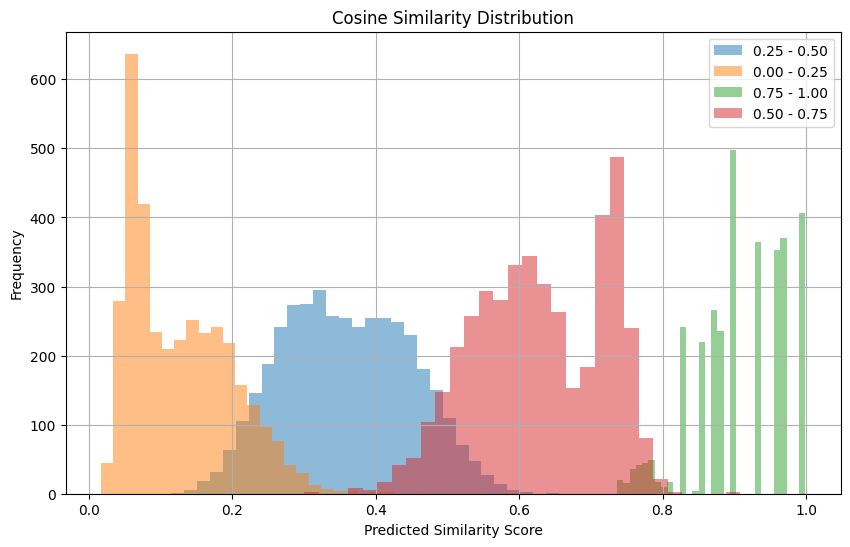

In [ ]:
# Membuat plot distribusi cosine similarity berdasarkan kelompok relevansi
plot_df = pd.DataFrame({
    "true_score": y_true,
    "pred_score": y_pred_scores
})

# Membuat kelompok relevansi
plot_df["relevance_group"] = pd.cut(
    plot_df["true_score"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "0.00 - 0.25",
        "0.25 - 0.50",
        "0.50 - 0.75",
        "0.75 - 1.00"
    ]
)

plt.figure(figsize=(10, 6))

for group in plot_df["relevance_group"].dropna().unique():

    subset = plot_df[
        plot_df["relevance_group"] == group
    ]

    plt.hist(
        subset["pred_score"],
        bins=30,
        alpha=0.5,
        label=group
    )

plt.title("Cosine Similarity Distribution")
plt.xlabel("Predicted Similarity Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# 5. Prediction vs Ground Truth

Visualisasi ini digunakan untuk membandingkan skor prediksi model dengan skor kecocokan sebenarnya pada data pengujian.

Setiap titik merepresentasikan satu pasangan CV dan lowongan pekerjaan. Garis diagonal menunjukkan kondisi prediksi ideal, yaitu ketika nilai prediksi sama dengan nilai target.

Semakin banyak titik yang berada di sekitar garis diagonal, semakin baik kemampuan model dalam memprediksi tingkat kecocokan antara CV dan lowongan pekerjaan.

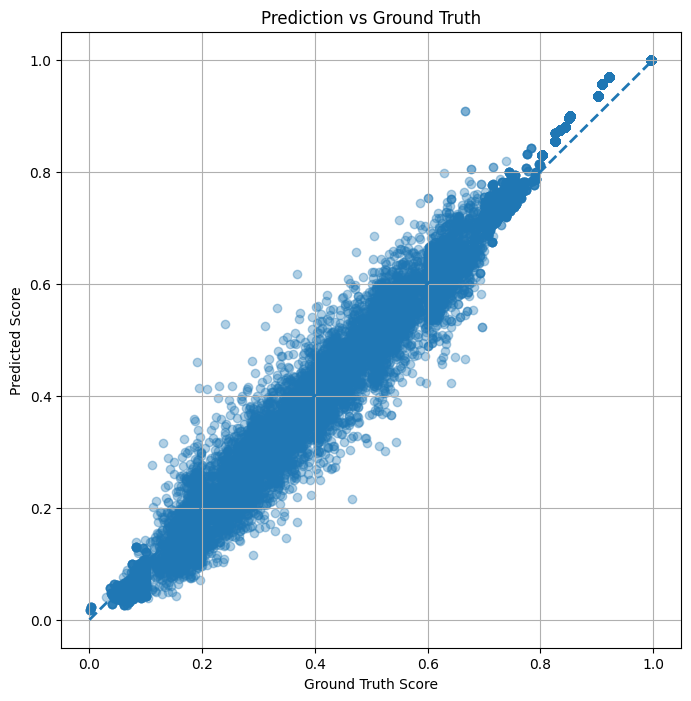

In [36]:
# Membuat plot scatter untuk membandingkan skor prediksi dengan label asli
plt.figure(figsize=(8, 8))

plt.scatter(
    y_true,
    y_pred_scores,
    alpha=0.35
)

# Garis prediksi
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Ground Truth Score")
plt.ylabel("Predicted Score")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.show()

## Kesimpulan Evaluasi Model

Berdasarkan hasil evaluasi pada 15.000 data uji, model Sentence-BERT yang telah di-fine-tuning menunjukkan performa yang sangat baik dalam memprediksi tingkat kecocokan antara CV dan lowongan pekerjaan. Model memperoleh nilai Test Loss (MSE) sebesar **0,0018**, Test MAE sebesar **0,0335**, dan Accuracy sebesar **96,09%**. Nilai MAE yang rendah menunjukkan bahwa rata-rata selisih antara skor prediksi dan skor target hanya sekitar **3,35%**, sehingga prediksi yang dihasilkan model cukup mendekati nilai relevansi sebenarnya.

Selain itu, model juga memperoleh **Pearson Correlation sebesar 0,9908** dan **Spearman Correlation sebesar 0,9901**. Hasil tersebut menunjukkan bahwa skor prediksi memiliki hubungan yang sangat kuat dengan skor relevansi aktual, serta mampu mempertahankan urutan ranking kecocokan dengan sangat baik. Hal ini penting karena sistem ITCareerMatch akan digunakan untuk mengurutkan lowongan pekerjaan berdasarkan tingkat kecocokan terhadap CV pengguna.

Hasil visualisasi *Cosine Similarity Distribution* menunjukkan bahwa model mampu membedakan pasangan CV dan lowongan dengan tingkat relevansi yang berbeda. Pasangan dengan relevansi rendah cenderung memperoleh skor prediksi yang rendah, sedangkan pasangan dengan relevansi tinggi memperoleh skor yang lebih tinggi. Sementara itu, grafik *Prediction vs Ground Truth* memperlihatkan bahwa sebagian besar titik berada di sekitar garis diagonal, yang menandakan bahwa skor prediksi model sangat dekat dengan nilai target yang sebenarnya.

Secara keseluruhan, hasil evaluasi menunjukkan bahwa model berhasil mempelajari hubungan semantik antara CV dan deskripsi pekerjaan dengan baik. Dengan tingkat akurasi yang tinggi, korelasi yang sangat kuat, serta kemampuan membedakan tingkat relevansi secara konsisten, model dinilai layak untuk digunakan sebagai mesin rekomendasi utama pada platform ITCareerMatch.